# Tweet Classification EDA

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

base_path = Path.cwd().parent  
sns.set_theme()



In [2]:
data_path = base_path / "data" / "sample_tweet.csv"

df = pd.read_csv(data_path, usecols=['Target', 'Text'], encoding='ISO-8859-1')
df.head()

,Target,Text
0,0,@maurat that is so sad but I'm glad that you ...
1,0,thats is sooooooooooooooo annoying. i hate loo...
2,0,@fingertippoetry http://twitpic.com/3p5or - no...
3,0,just saw an amazing jacket that he looks damn ...
4,0,@erika_lukanov I've gotta work at 5 AM My ne...


In [3]:
df['Target'] = df['Target'].mask(df['Target'] ==4, 1)

In [4]:
df['Target'].value_counts()

Target
0    140000
1     62144
Name: count, dtype: int64

In [5]:
df['total_words'] = df['Text'].apply(lambda text: len(text.split()))
df['total_exclaim'] = df['Text'].apply(lambda text: len(re.findall(r"!", text)))
df['total_xters'] = df['Text'].apply(lambda text: len(re.findall(r"[^\s]", text)))


In [6]:
EMOJI_PATTERN = re.compile(
     "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
) 

def contains_emoji(text):
    return int(bool(EMOJI_PATTERN.search(text)))

df["has_emoji"] = df['Text'].apply(contains_emoji)

In [7]:
df.head()

,Target,Text,total_words,total_exclaim,total_xters,has_emoji
0,0,@maurat that is so sad but I'm glad that you ...,13,0,56,0
1,0,thats is sooooooooooooooo annoying. i hate loo...,10,0,62,0
2,0,@fingertippoetry http://twitpic.com/3p5or - no...,15,0,92,0
3,0,just saw an amazing jacket that he looks damn ...,17,0,66,0
4,0,@erika_lukanov I've gotta work at 5 AM My ne...,20,0,80,0


In [8]:
df.has_emoji.value_counts()

has_emoji
0    202144
Name: count, dtype: int64

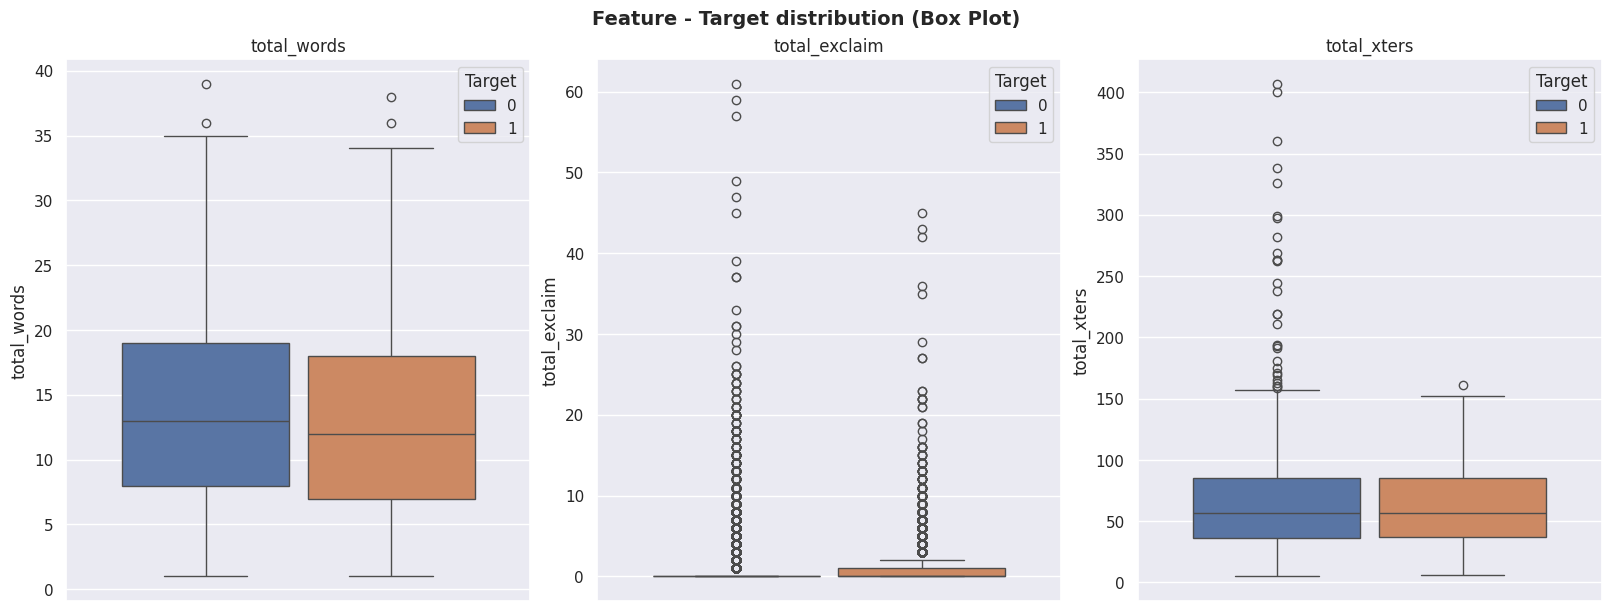

In [9]:
fig = plt.figure(figsize=[16, 6], layout="constrained")
features = ["total_words", "total_exclaim", "total_xters"] 

for idx, feature in zip(range(1, len(features)+1), features):
    ax = plt.subplot(1, 3, idx)
    sns.boxplot(data=df, y=feature, hue="Target", ax=ax, gap=0.1)
    ax.set_title(feature)

plt.suptitle('Feature - Target distribution (Box Plot)', fontsize=14, fontweight='bold')
plt.show()

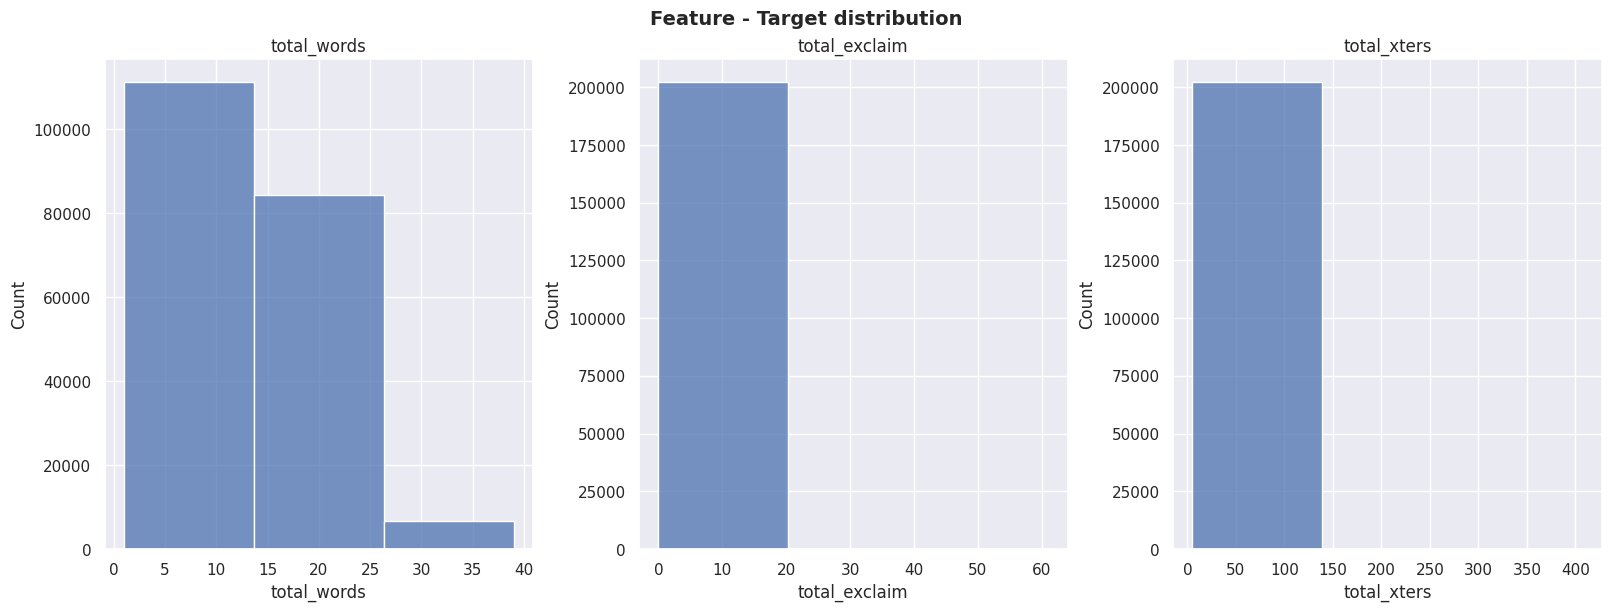

In [10]:
fig = plt.figure(figsize=[16, 6], layout="constrained")
features = ["total_words", "total_exclaim", "total_xters"] 

for idx, feature in zip(range(1, len(features)+1), features):
    ax = plt.subplot(1, 3, idx)
    sns.histplot(data=df, x=feature, ax=ax, bins=3 )
    ax.set_title(feature)

plt.suptitle('Feature - Target distribution', fontsize=14, fontweight='bold')
plt.show()

### Summary
The dataset contains only two classes either as negative (0) or positive (1).  The positive class is about one-third of the entire dataset. The feature distribution between the positive and negative classes spanned similar ranges. However, the boxplot for the number of exclaim show that the positive classes has the highest number of tweets with an exclamation as against the negative class.  

In the distribution of the features for the entire dataset, binned into three classes, the histogram plots are all skewed to the right with most tweets using fewer than 25 total words and few exclaims and number of characters. 